In [2]:
# ── Upload your CSV file ──────────────────────────────────────
from google.colab import files
uploaded = files.upload()
# Upload: final_merged_jobs.csv


Saving final_merged_jobs.csv to final_merged_jobs.csv


In [3]:
# ── Install & Import All Libraries ───────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

plt.rcParams['figure.dpi']  = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')

# Colour palette
CITY_COLORS   = ['#4E79A7','#F28E2B','#E15759','#76B7B2']
PORTAL_COLORS = ['#FF5733','#0A66C2','#E8423F','#0CAA41','#003A9B']
BG            = '#F7F9FC'
ACCENT        = '#2C3E50'
CITIES        = ['Surat','Ahmedabad','Vadodara','Gandhinagar']
PORTALS       = ['Internshala','Naukri','Indeed','LinkedIn','Glassdoor']

print('✅ Libraries loaded!')

✅ Libraries loaded!


In [4]:
df = pd.read_csv('final_merged_jobs.csv')
df['date_posted']       = pd.to_datetime(df['date_posted'], errors='coerce')
df['salary_lpa']        = df['salary_annual_inr'] / 100_000
df['experience_years']  = pd.to_numeric(df['experience_years'], errors='coerce').fillna(0)

print('=' * 55)
print('   DATASET OVERVIEW')
print('=' * 55)
print(f'  Total Records    : {len(df):,}')
print(f'  Total Columns    : {df.shape[1]}')
print(f'  Cities           : {df["city"].value_counts().to_dict()}')
print(f'  Portals          : {df["source_portal"].value_counts().to_dict()}')
print(f'  Domains          : {df["job_domain"].nunique()}')
print(f'  Date Range       : {df["date_posted"].min().date()} → {df["date_posted"].max().date()}')
print(f'  Jobs with Salary : {df["salary_annual_inr"].notna().sum():,}')
print(f'  Internships      : {df[df["job_type"]=="Internship"].shape[0]:,}')
print('=' * 55)
df.head()

   DATASET OVERVIEW
  Total Records    : 6,647
  Total Columns    : 15
  Cities           : {'Surat': 1688, 'Ahmedabad': 1688, 'Vadodara': 1638, 'Gandhinagar': 1633}
  Portals          : {'Internshala': 1793, 'Naukri': 1428, 'Indeed': 1199, 'LinkedIn': 1125, 'Glassdoor': 1102}
  Domains          : 20
  Date Range       : 2026-01-08 → 2026-03-24
  Jobs with Salary : 5,558
  Internships      : 1,078


,job_title,company_name,location,city,experience,salary,skills,job_description,job_domain,job_type,date_posted,source_portal,experience_years,salary_annual_inr,salary_lpa
0,Test Analyst,Mobisoft Infotech,"Surat, Gujarat, India",Surat,Fresher / 0-1 years,3.6-4.6 LPA,"Playwright, TypeScript, API Testing, CI/CD, Gi...",Join our growing team as a Test Analyst based ...,QA / Software Testing,Full-time,2026-03-03,Naukri,0.0,410000.0,4.1
1,Technical Product Manager,Synarion IT Solutions,"Surat, Gujarat, India",Surat,1-3 years,4.9-7.7 LPA,"Scrum Master, Agile Coaching, Sprint Planning,...",Exciting opportunity for a talented Technical ...,Product Management,Full-time,2026-03-09,Naukri,1.0,630000.0,6.3
2,ServiceNow Developer,Synarion IT Solutions,"Surat, Gujarat, India",Surat,0-1 years,2.2-5.2 LPA,"SAP BTP, SAP Integration Suite, MuleSoft, Dell...",Exciting opportunity for a talented ServiceNow...,ERP / Enterprise Systems,Full-time,2026-02-10,Naukri,0.0,370000.0,3.7
3,NoSQL Engineer,Mindinventory,"Surat, Gujarat, India",Surat,3-5 years,Not Disclosed,"PostgreSQL, PgBouncer, Patroni, Replication, Q...",We are looking for a passionate NoSQL Engineer...,Database Administration,Full-time,2026-03-24,Naukri,3.0,NaN,NaN
4,SQL Server DBA,WebMob Technologies,"Surat, Gujarat, India",Surat,3-5 years,7.0-14.0 LPA,"Oracle DBA, PL/SQL, RAC, ASM, Data Guard, RMAN...",Join our growing team as a SQL Server DBA base...,Database Administration,Full-time,2026-03-22,Naukri,3.0,1050000.0,10.5


In [5]:
print('=== CITY DISTRIBUTION ===')
print(df['city'].value_counts())
print('\n=== PORTAL DISTRIBUTION ===')
print(df['source_portal'].value_counts())
print('\n=== TOP 10 DOMAINS ===')
print(df['job_domain'].value_counts().head(10))
print('\n=== JOB TYPES ===')
print(df['job_type'].value_counts())
print('\n=== SALARY STATS (LPA) ===')
sal = df[df['salary_lpa']>0]['salary_lpa']
print(sal.describe().round(2))

=== CITY DISTRIBUTION ===
city
Surat          1688
Ahmedabad      1688
Vadodara       1638
Gandhinagar    1633
Name: count, dtype: int64

=== PORTAL DISTRIBUTION ===
source_portal
Internshala    1793
Naukri         1428
Indeed         1199
LinkedIn       1125
Glassdoor      1102
Name: count, dtype: int64

=== TOP 10 DOMAINS ===
job_domain
Web Development                               688
Software Development                          675
Data Analytics                                504
Cloud Computing                               462
DevOps                                        392
Data Science                                  386
ERP / Enterprise Systems                      374
Artificial Intelligence / Machine Learning    363
QA / Software Testing                         358
Cybersecurity                                 349
Name: count, dtype: int64

=== JOB TYPES ===
job_type
Full-time     4118
Internship    1078
Contract       895
Part-time      556
Name: count, dtype: int64

==

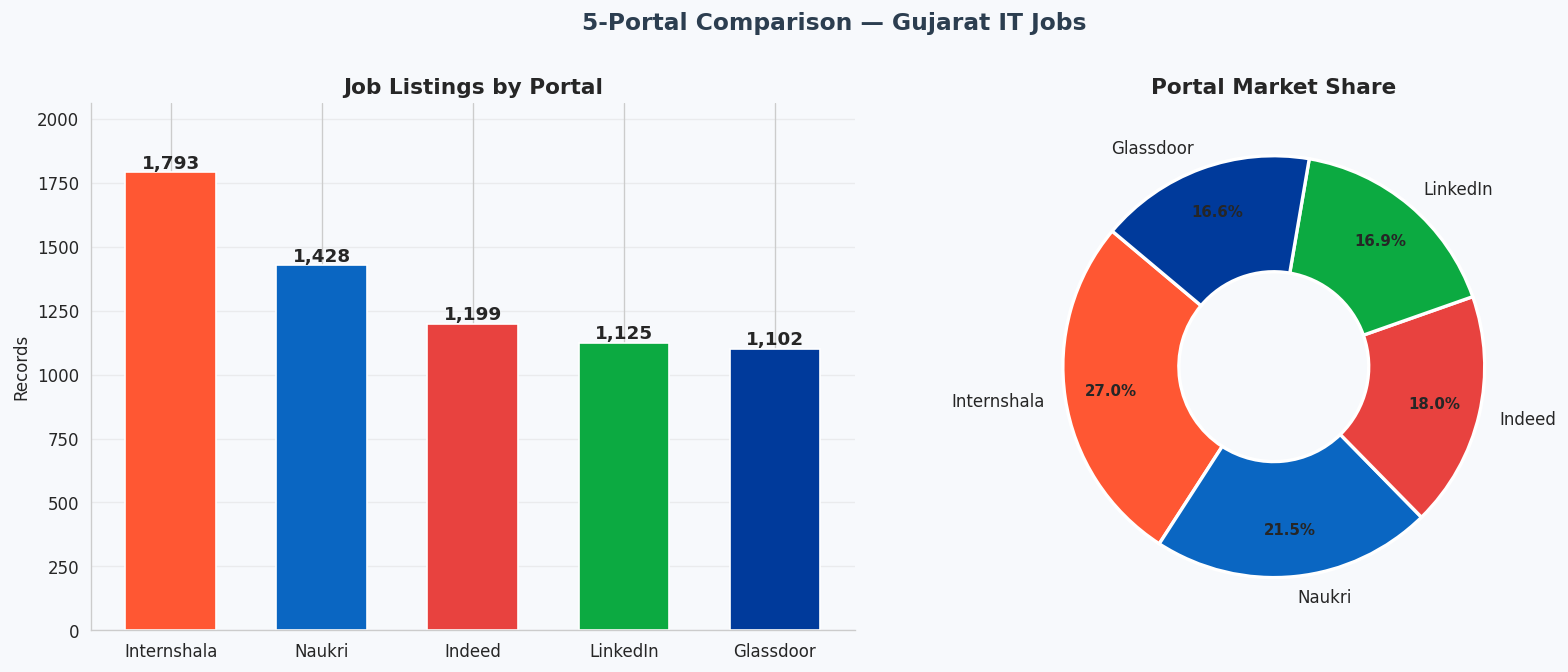

In [6]:
portal_counts = df['source_portal'].value_counts().reindex(PORTALS).dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.patch.set_facecolor(BG)

# Bar chart
ax = axes[0]
ax.set_facecolor(BG)
bars = ax.bar(portal_counts.index, portal_counts.values,
              color=PORTAL_COLORS, edgecolor='white', width=0.6)
for bar, val in zip(bars, portal_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+15, f'{int(val):,}',
            ha='center', fontweight='bold', fontsize=11)
ax.set_title('Job Listings by Portal', fontweight='bold', fontsize=13)
ax.set_ylabel('Records')
ax.set_ylim(0, portal_counts.max()*1.15)
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)

# Pie chart
axes[1].set_facecolor(BG)
wedges, _, autotexts = axes[1].pie(
    portal_counts.values, labels=portal_counts.index,
    colors=PORTAL_COLORS, autopct='%1.1f%%', startangle=140,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2),
    pctdistance=0.78)
for at in autotexts:
    at.set_fontsize(9); at.set_fontweight('bold')
axes[1].set_title('Portal Market Share', fontweight='bold', fontsize=13)

plt.suptitle('5-Portal Comparison — Gujarat IT Jobs',
             fontsize=14, fontweight='bold', color=ACCENT, y=1.01)
plt.tight_layout()
plt.show()

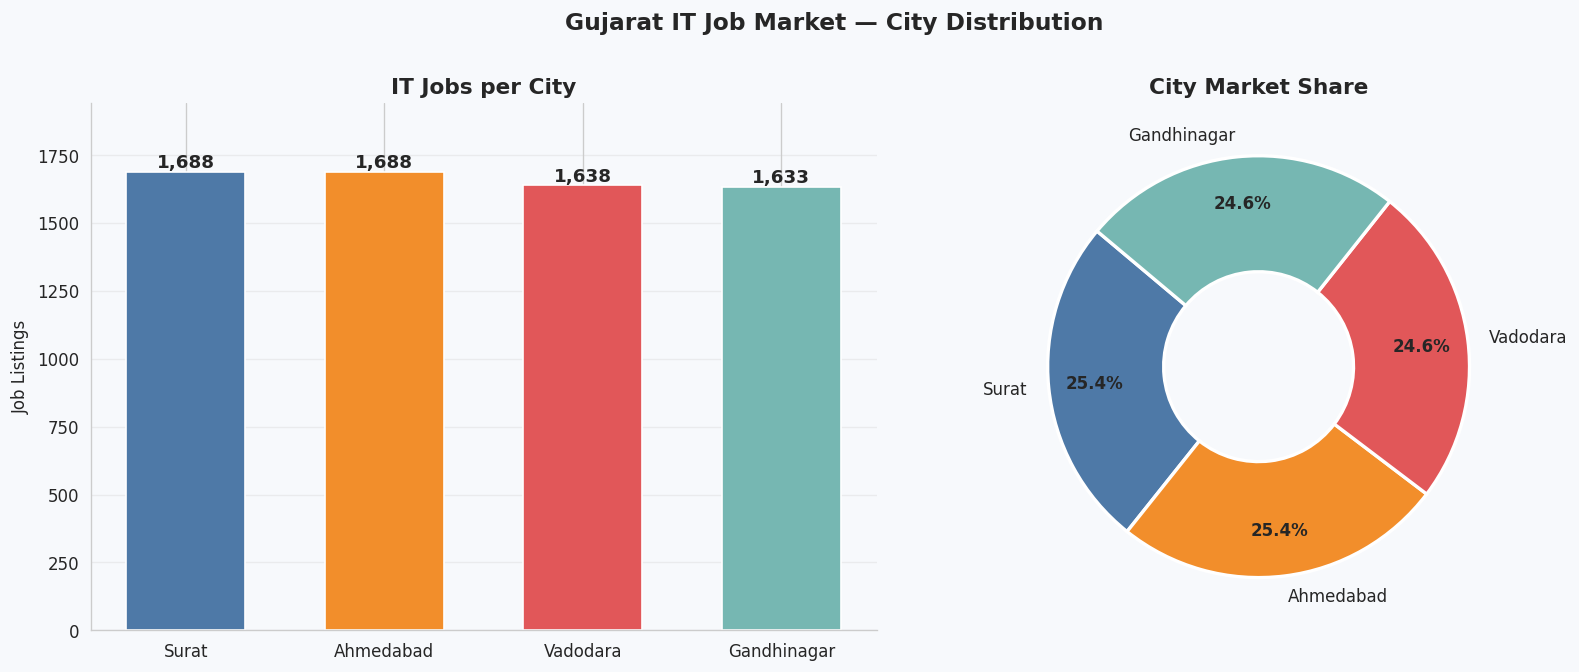

In [7]:
city_counts = df['city'].value_counts().reindex(CITIES)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.patch.set_facecolor(BG)

ax = axes[0]
ax.set_facecolor(BG)
bars = ax.bar(city_counts.index, city_counts.values,
              color=CITY_COLORS, edgecolor='white', width=0.6)
for bar, val in zip(bars, city_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+15, f'{int(val):,}',
            ha='center', fontweight='bold', fontsize=11)
ax.set_title('IT Jobs per City', fontweight='bold', fontsize=13)
ax.set_ylabel('Job Listings')
ax.set_ylim(0, city_counts.max()*1.15)
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)

axes[1].set_facecolor(BG)
_, _, autotexts = axes[1].pie(
    city_counts.values, labels=city_counts.index,
    colors=CITY_COLORS, autopct='%1.1f%%', startangle=140,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2),
    pctdistance=0.78)
for at in autotexts:
    at.set_fontsize(10); at.set_fontweight('bold')
axes[1].set_title('City Market Share', fontweight='bold', fontsize=13)

plt.suptitle('Gujarat IT Job Market — City Distribution',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

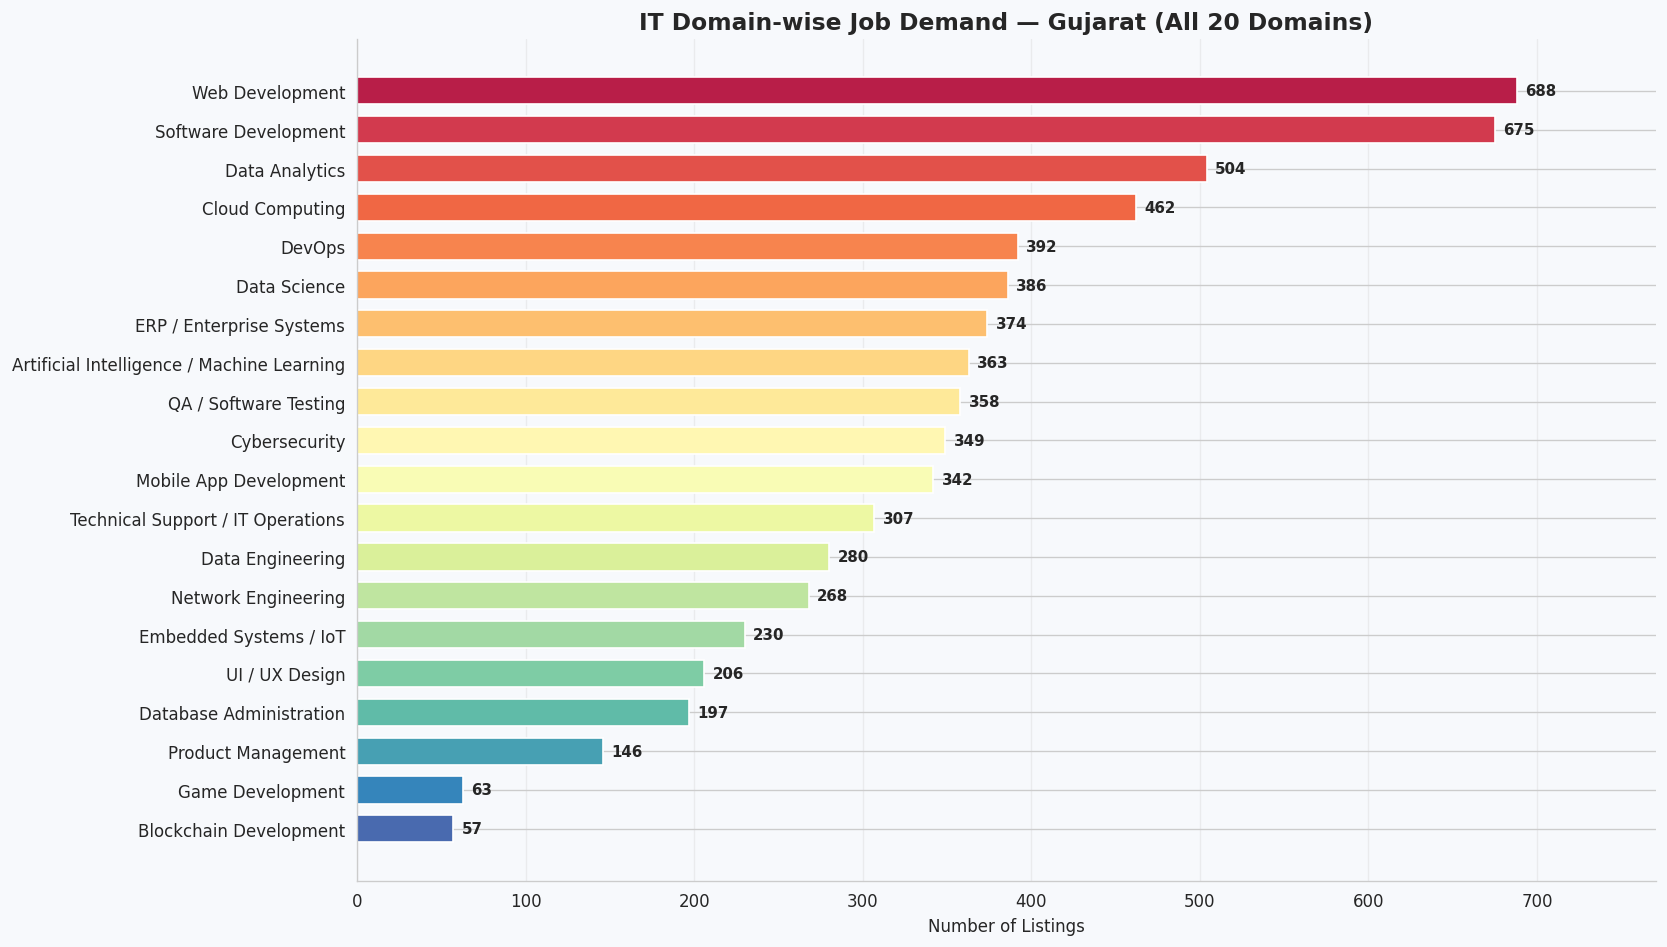

In [8]:
domain_counts = df['job_domain'].value_counts()

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
colors_d = sns.color_palette('Spectral', len(domain_counts))
bars = ax.barh(domain_counts.index[::-1], domain_counts.values[::-1],
               color=colors_d[::-1], edgecolor='white', height=0.7)
for bar, val in zip(bars, domain_counts.values[::-1]):
    ax.text(bar.get_width()+5, bar.get_y()+bar.get_height()/2,
            str(int(val)), va='center', fontsize=9, fontweight='bold')
ax.set_title('IT Domain-wise Job Demand — Gujarat (All 20 Domains)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Listings')
ax.set_xlim(0, domain_counts.max()*1.12)
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

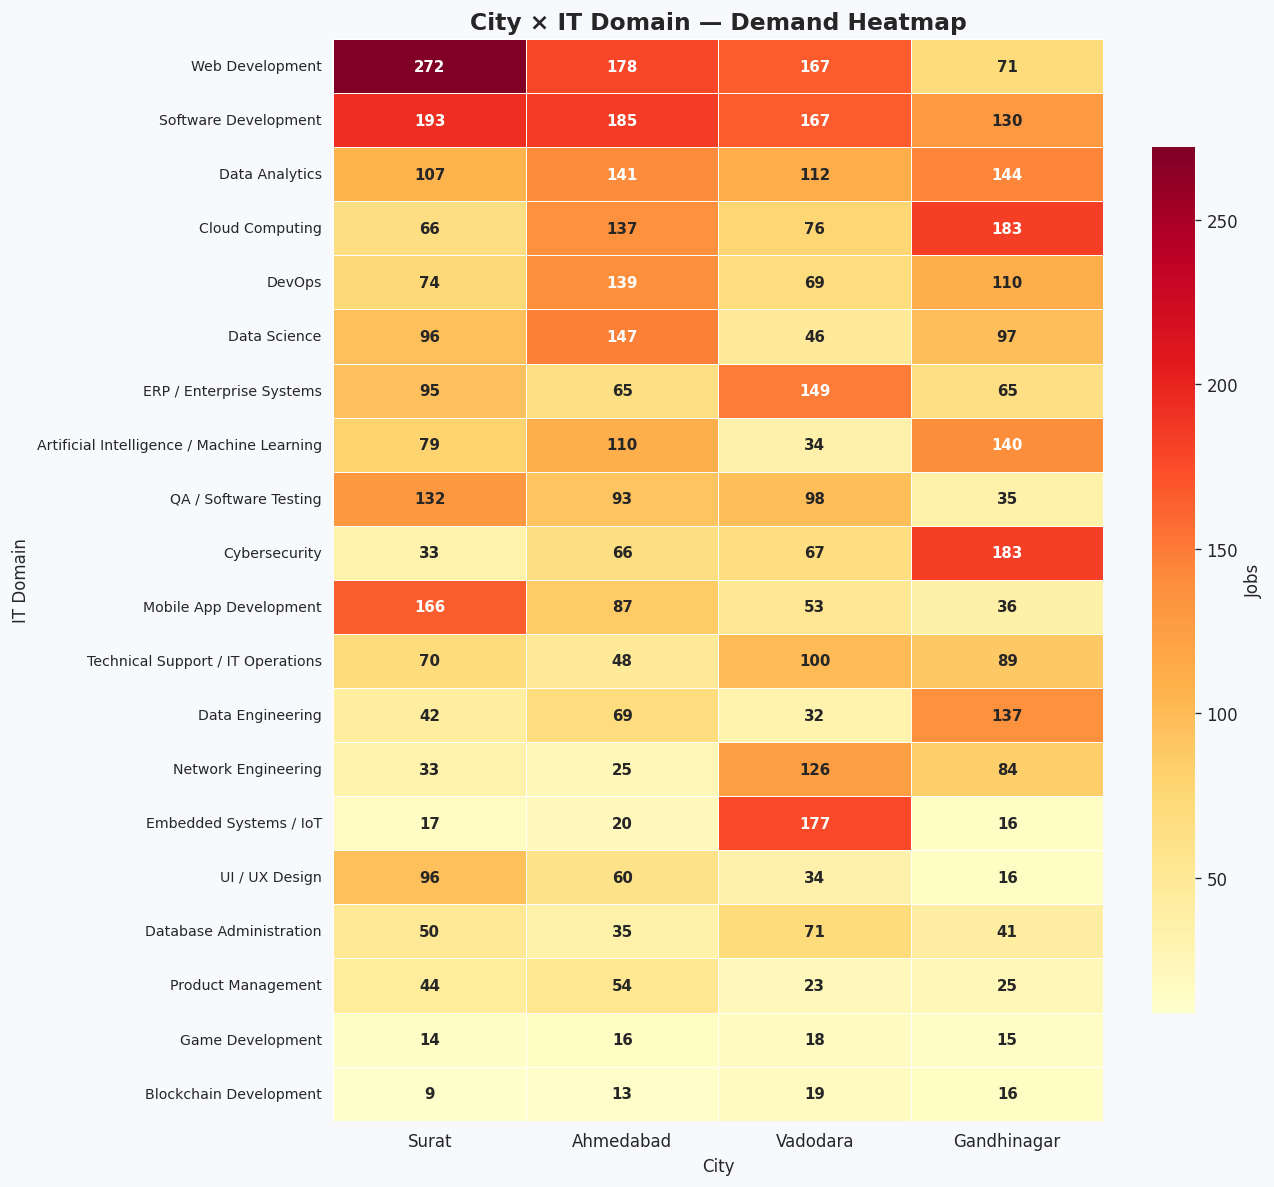

In [9]:
pivot = df.pivot_table(index='job_domain', columns='city',
                        values='job_title', aggfunc='count', fill_value=0)
pivot = pivot.reindex(columns=CITIES, fill_value=0)
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(11, 10))
fig.patch.set_facecolor(BG)
sns.heatmap(pivot, ax=ax, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label':'Jobs','shrink':0.8},
            annot_kws={'size':9, 'weight':'bold'})
ax.set_title('City × IT Domain — Demand Heatmap',
             fontsize=14, fontweight='bold')
ax.set_xlabel('City'); ax.set_ylabel('IT Domain')
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0, labelsize=8.5)
plt.tight_layout()
plt.show()

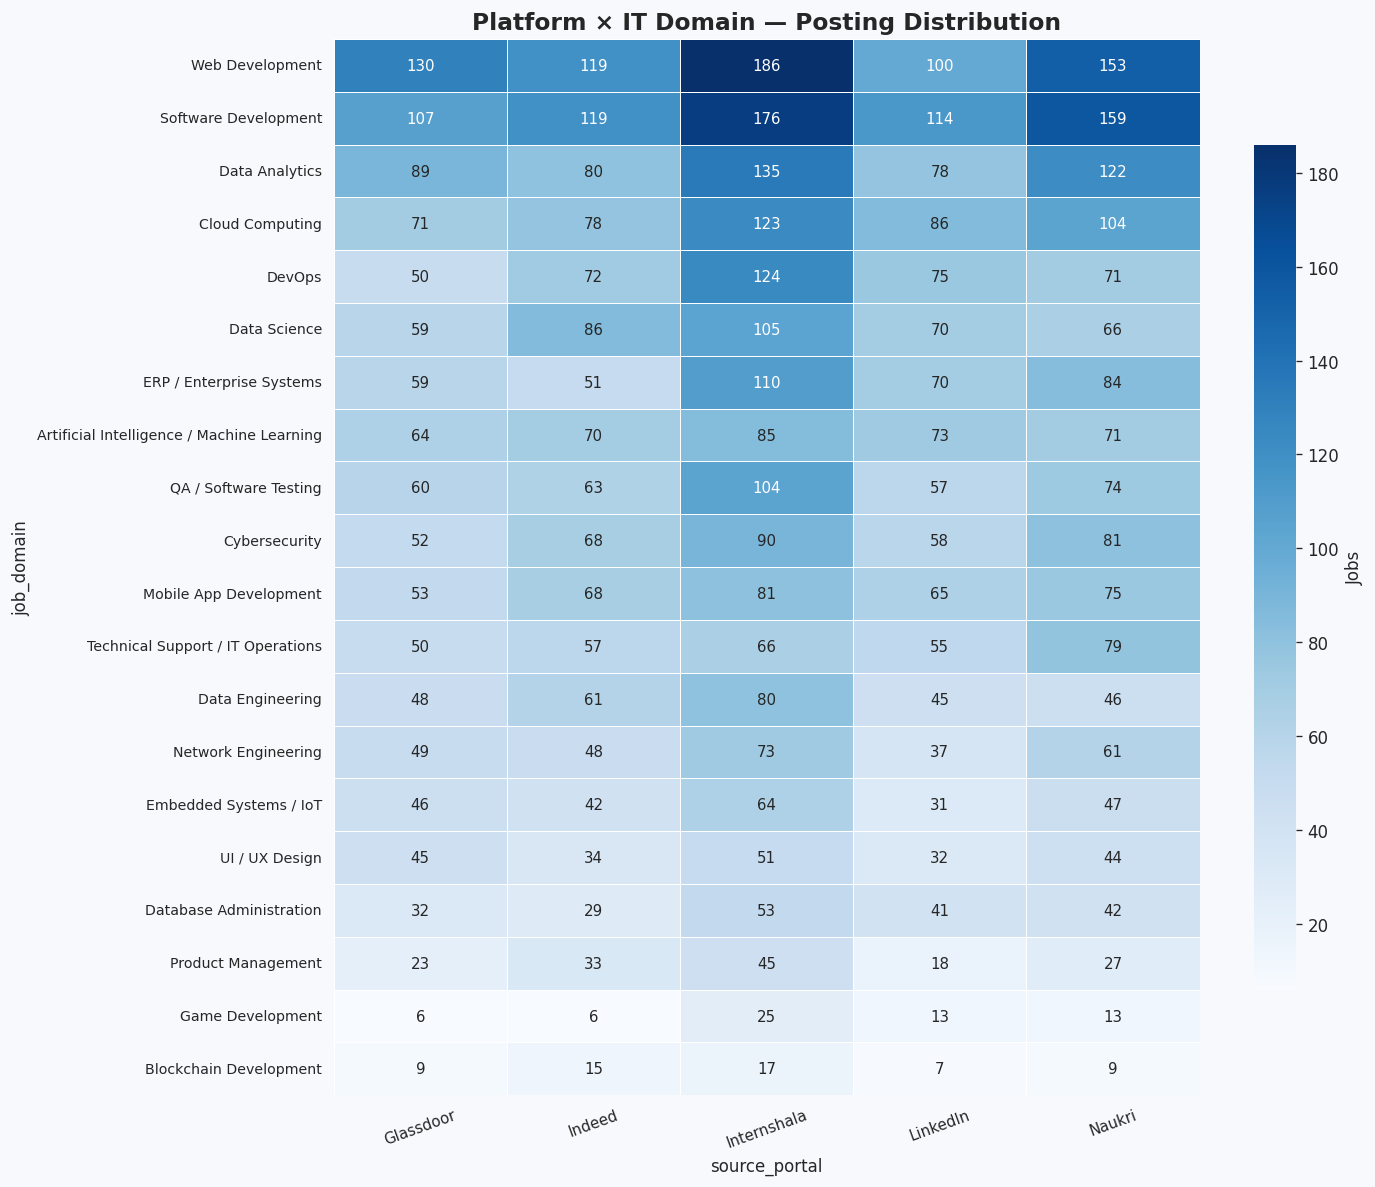

In [10]:
pivot2 = df.pivot_table(index='job_domain', columns='source_portal',
                         values='job_title', aggfunc='count', fill_value=0)
pivot2 = pivot2.loc[pivot2.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(12, 10))
fig.patch.set_facecolor(BG)
sns.heatmap(pivot2, ax=ax, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label':'Jobs','shrink':0.8},
            annot_kws={'size':9})
ax.set_title('Platform × IT Domain — Posting Distribution',
             fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=20, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=8.5)
plt.tight_layout()
plt.show()

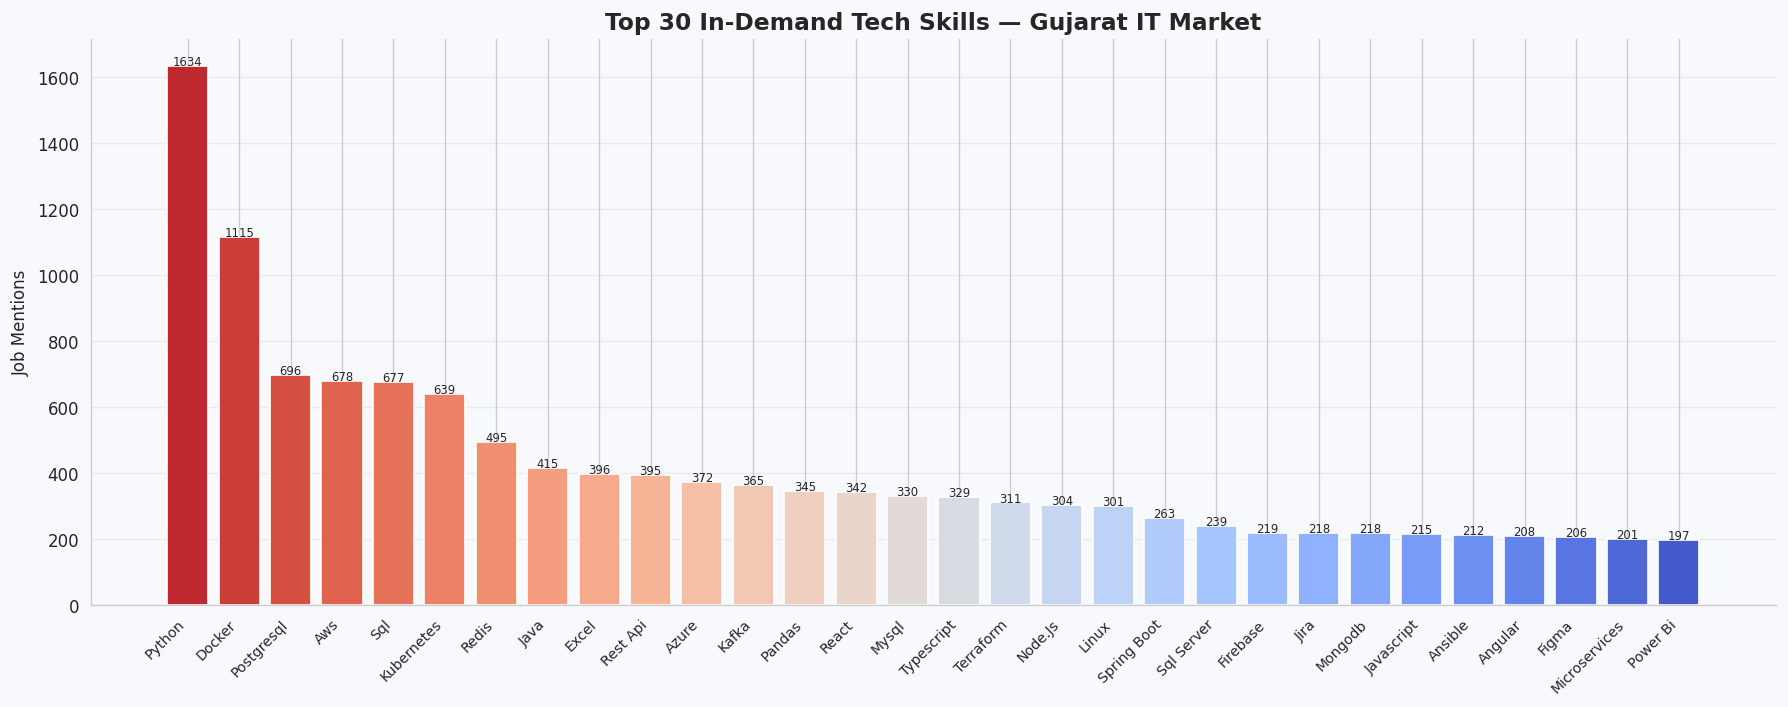


🔥 Top 10 Skills: Python, Docker, Postgresql, Aws, Sql, Kubernetes, Redis, Java, Excel, Rest Api


In [11]:
all_skills = (df['skills'].dropna()
              .str.split(', ').explode()
              .str.strip().str.title()
              .value_counts())
top30 = all_skills.head(30)

fig, ax = plt.subplots(figsize=(15, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
colors_s = sns.color_palette('coolwarm_r', 30)
bars = ax.bar(range(30), top30.values, color=colors_s, edgecolor='white')
ax.set_xticks(range(30))
ax.set_xticklabels(top30.index, rotation=45, ha='right', fontsize=8.5)
for bar, val in zip(bars, top30.values):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+3, str(int(val)),
            ha='center', fontsize=7)
ax.set_title('Top 30 In-Demand Tech Skills — Gujarat IT Market',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Job Mentions')
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\n🔥 Top 10 Skills: {", ".join(top30.head(10).index.tolist())}')

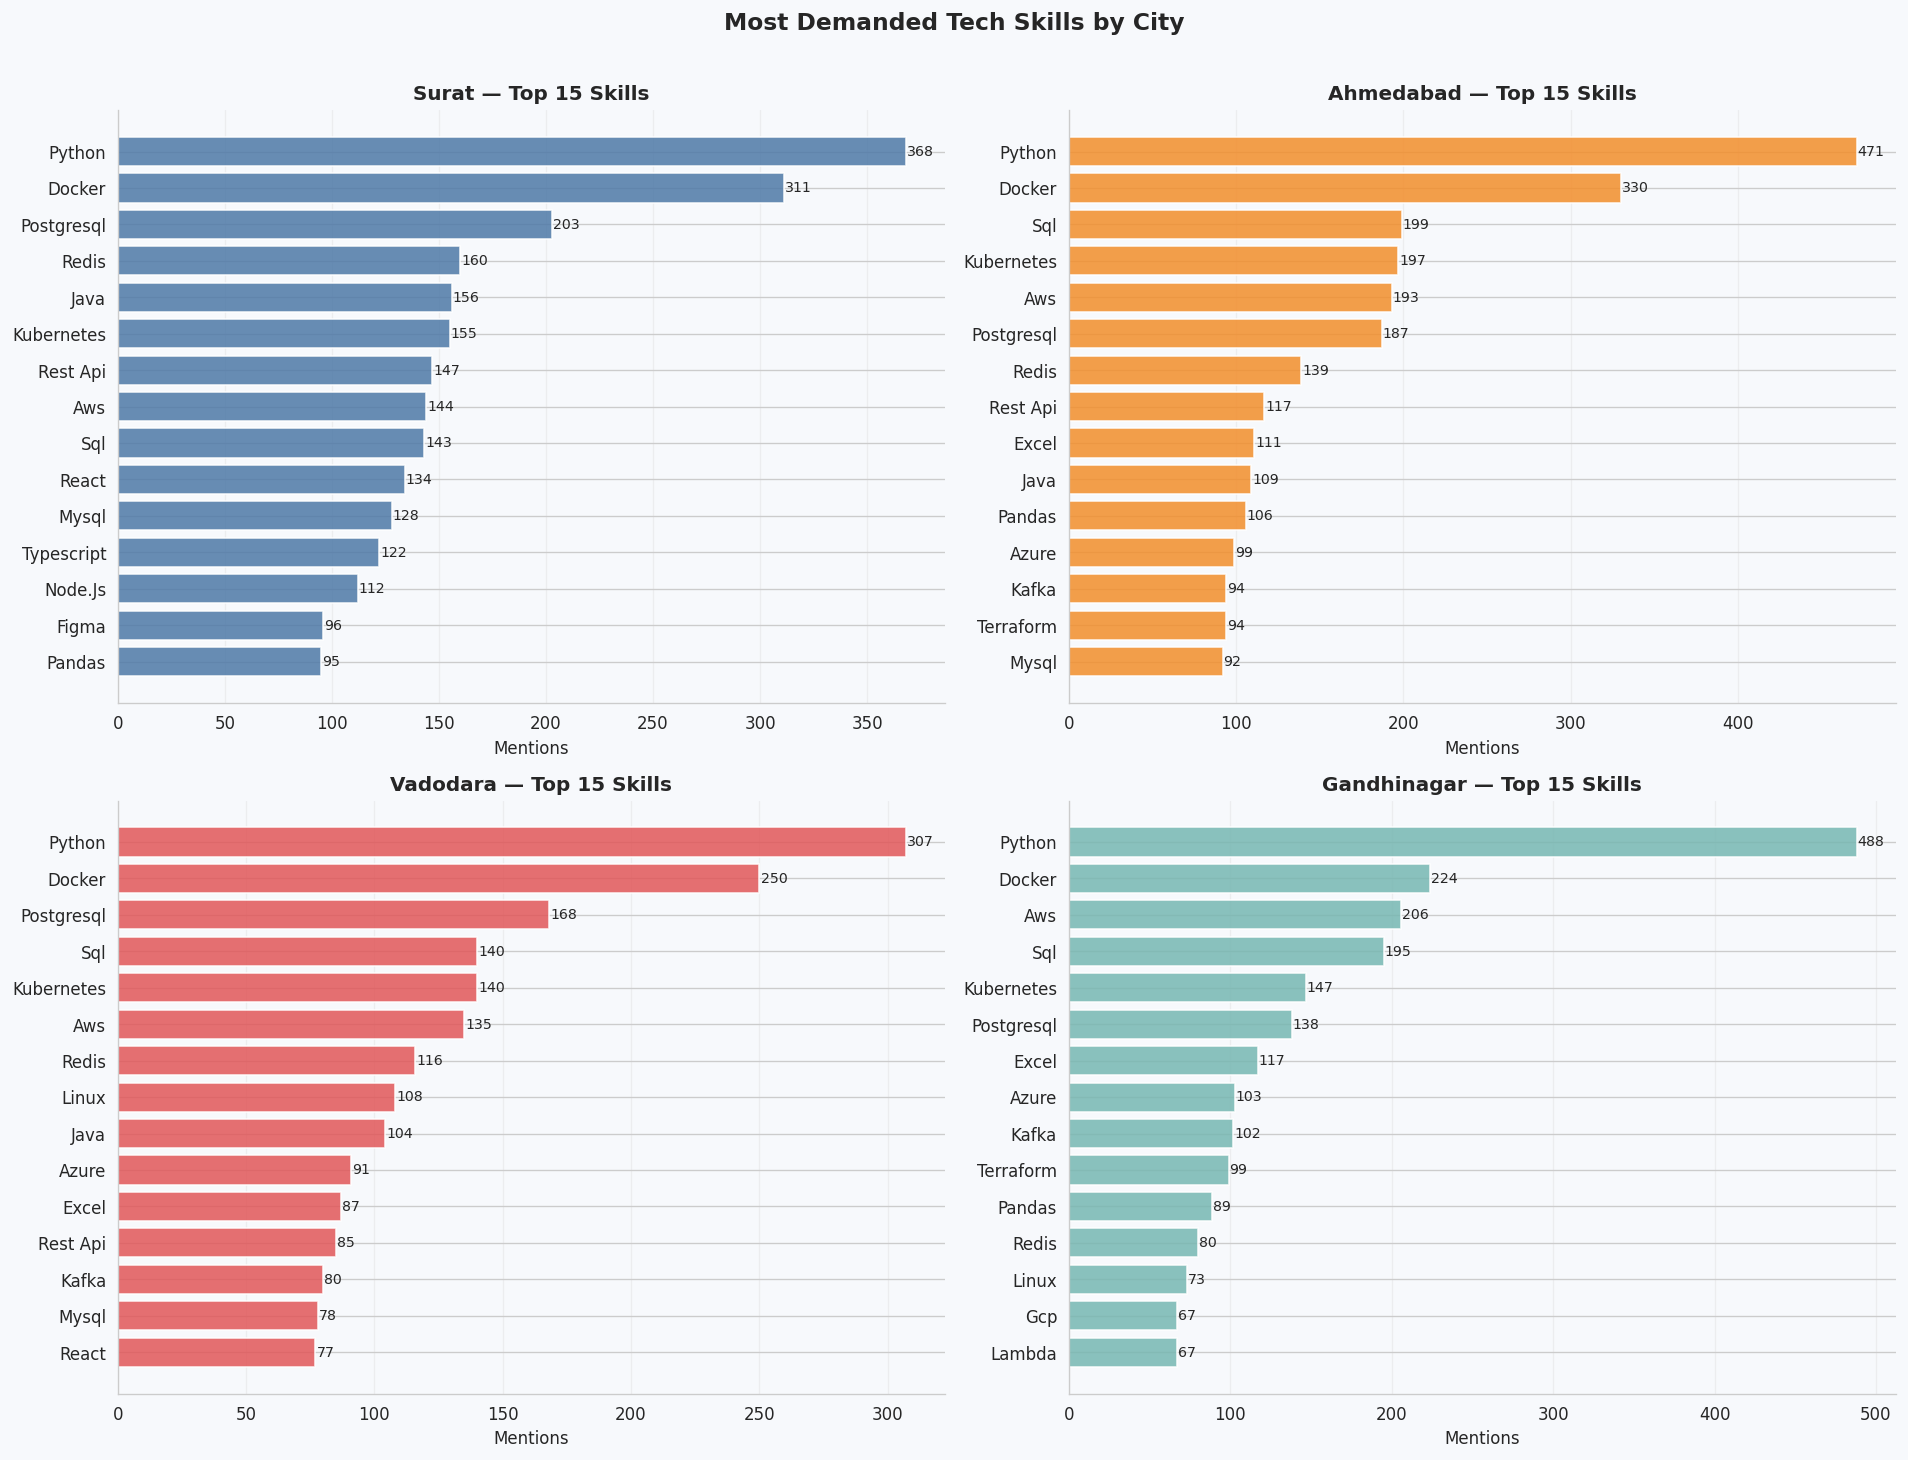

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor(BG)

for ax, (city, color) in zip(axes.flat, zip(CITIES, CITY_COLORS)):
    ax.set_facecolor(BG)
    city_skills = (df[df['city']==city]['skills']
                   .dropna().str.split(', ').explode()
                   .str.strip().str.title()
                   .value_counts().head(15))
    bars = ax.barh(city_skills.index[::-1], city_skills.values[::-1],
                   color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, city_skills.values[::-1]):
        ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
                str(int(val)), va='center', fontsize=8.5)
    ax.set_title(f'{city} — Top 15 Skills', fontweight='bold', fontsize=12)
    ax.set_xlabel('Mentions')
    ax.spines[['top','right']].set_visible(False)
    ax.grid(axis='x', alpha=0.25)

plt.suptitle('Most Demanded Tech Skills by City',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

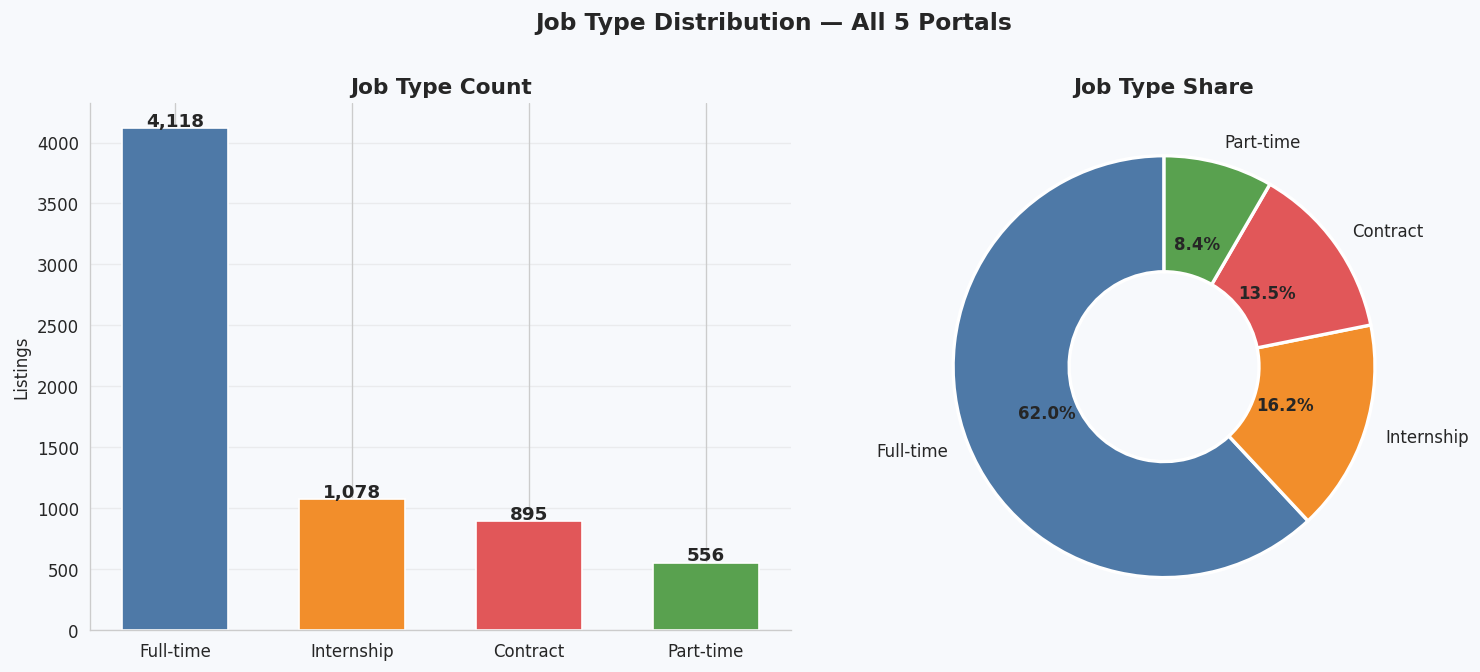

In [13]:
jt_counts   = df['job_type'].value_counts()
type_colors = ['#4E79A7','#F28E2B','#E15759','#59A14F']

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.patch.set_facecolor(BG)

ax = axes[0]
ax.set_facecolor(BG)
bars = ax.bar(jt_counts.index, jt_counts.values,
              color=type_colors[:len(jt_counts)],
              edgecolor='white', width=0.6)
for bar, val in zip(bars, jt_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+15, f'{int(val):,}',
            ha='center', fontweight='bold', fontsize=11)
ax.set_title('Job Type Count', fontweight='bold', fontsize=13)
ax.set_ylabel('Listings')
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)

axes[1].set_facecolor(BG)
_, _, autotexts = axes[1].pie(
    jt_counts.values, labels=jt_counts.index,
    colors=type_colors[:len(jt_counts)],
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2))
for at in autotexts:
    at.set_fontsize(10); at.set_fontweight('bold')
axes[1].set_title('Job Type Share', fontweight='bold', fontsize=13)

plt.suptitle('Job Type Distribution — All 5 Portals',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

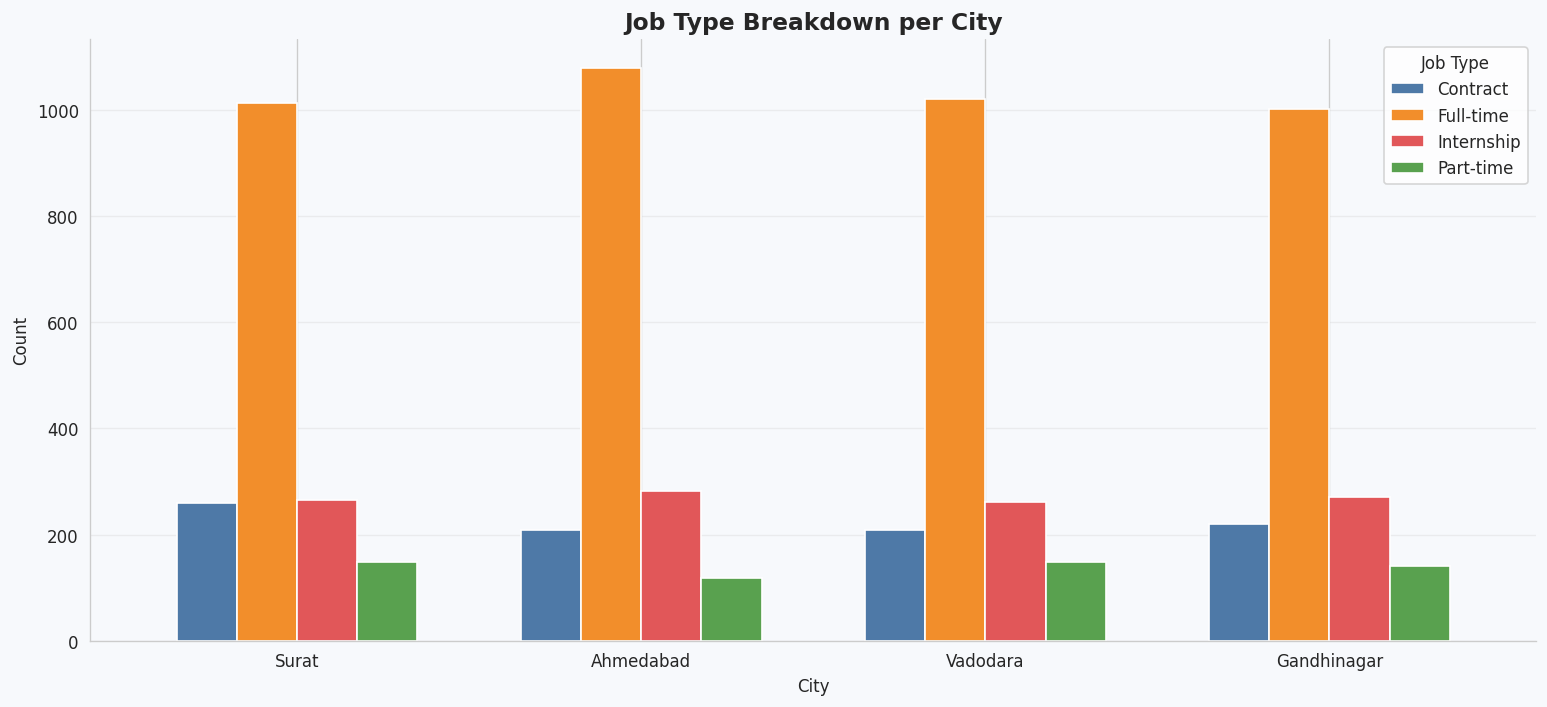

In [14]:
pivot_jt = df.pivot_table(index='city', columns='job_type',
                           values='job_title', aggfunc='count',
                           fill_value=0).reindex(CITIES)

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
pivot_jt.plot(kind='bar', ax=ax,
              color=type_colors[:len(pivot_jt.columns)],
              edgecolor='white', width=0.7)
ax.set_title('Job Type Breakdown per City',
             fontsize=14, fontweight='bold')
ax.set_xlabel('City'); ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Job Type', fontsize=10)
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

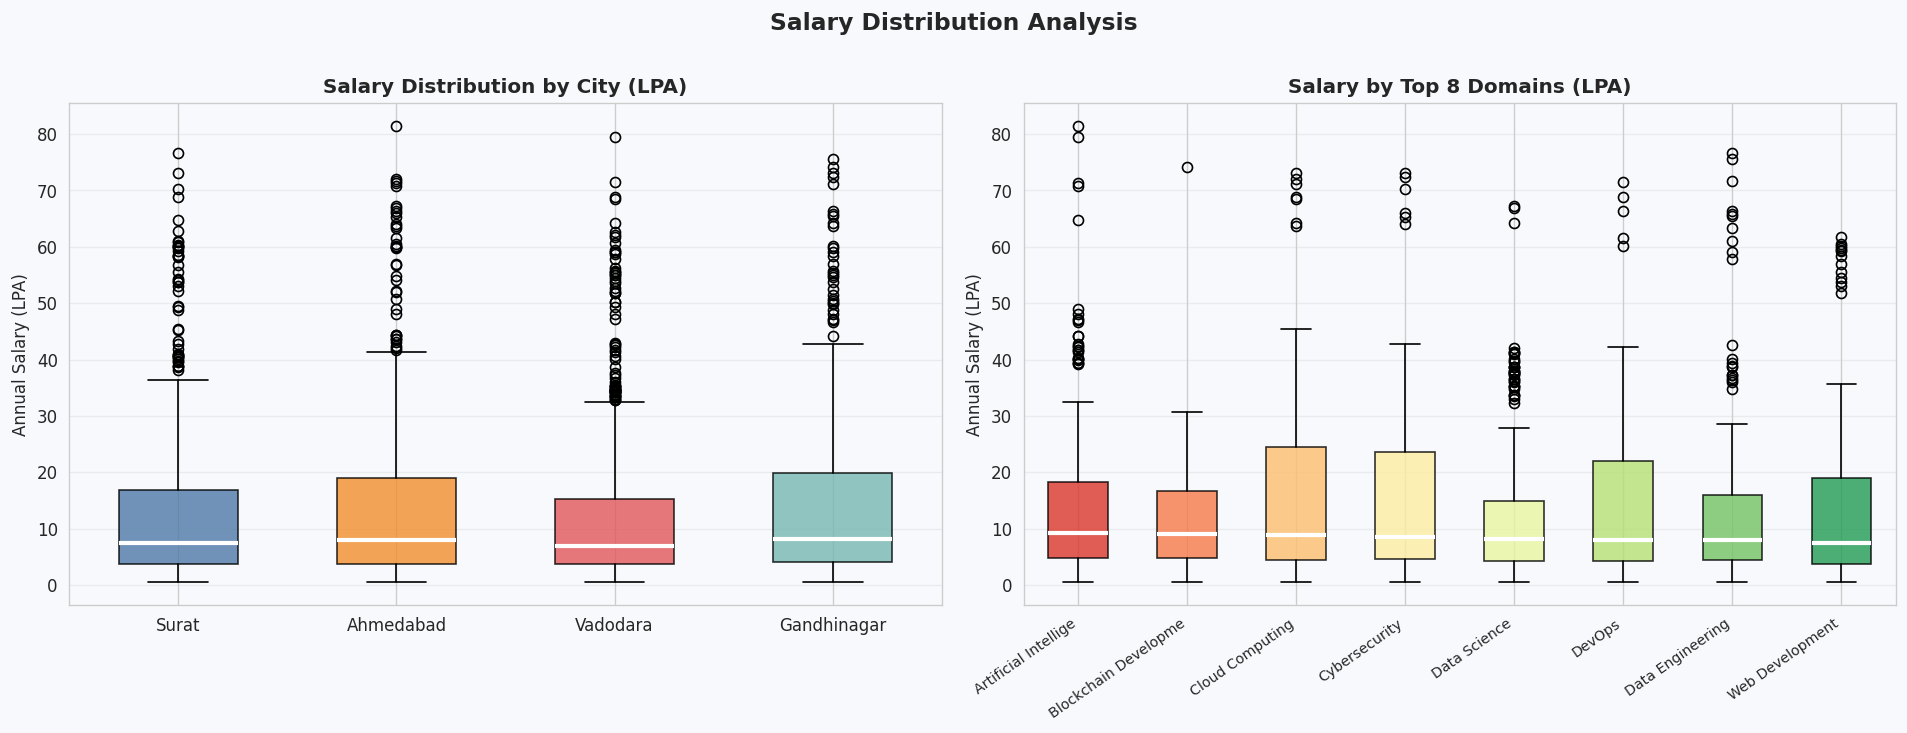

In [15]:
sal_df = df[df['salary_lpa'] > 0.5].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(BG)

# By City
ax = axes[0]
ax.set_facecolor(BG)
data_city = [sal_df[sal_df['city']==c]['salary_lpa'].dropna().values
             for c in CITIES]
bp = ax.boxplot(data_city, patch_artist=True, notch=False, widths=0.55)
for patch, color in zip(bp['boxes'], CITY_COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.8)
for med in bp['medians']:
    med.set_color('white'); med.set_linewidth(2.5)
ax.set_xticklabels(CITIES, fontsize=10)
ax.set_title('Salary Distribution by City (LPA)',
             fontweight='bold', fontsize=12)
ax.set_ylabel('Annual Salary (LPA)')
ax.grid(axis='y', alpha=0.3)

# Top 8 domains by median salary
ax2 = axes[1]
ax2.set_facecolor(BG)
top8_dom = sal_df.groupby('job_domain')['salary_lpa'].median().nlargest(8).index
data_dom = [sal_df[sal_df['job_domain']==d]['salary_lpa'].dropna().values
            for d in top8_dom]
bp2 = ax2.boxplot(data_dom, patch_artist=True, notch=False, widths=0.55)
colors_8 = sns.color_palette('RdYlGn', 8)
for patch, color in zip(bp2['boxes'], colors_8):
    patch.set_facecolor(color); patch.set_alpha(0.8)
for med in bp2['medians']:
    med.set_color('white'); med.set_linewidth(2.5)
ax2.set_xticklabels([d[:20] for d in top8_dom],
                    rotation=35, ha='right', fontsize=8.5)
ax2.set_title('Salary by Top 8 Domains (LPA)',
              fontweight='bold', fontsize=12)
ax2.set_ylabel('Annual Salary (LPA)')
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Salary Distribution Analysis',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

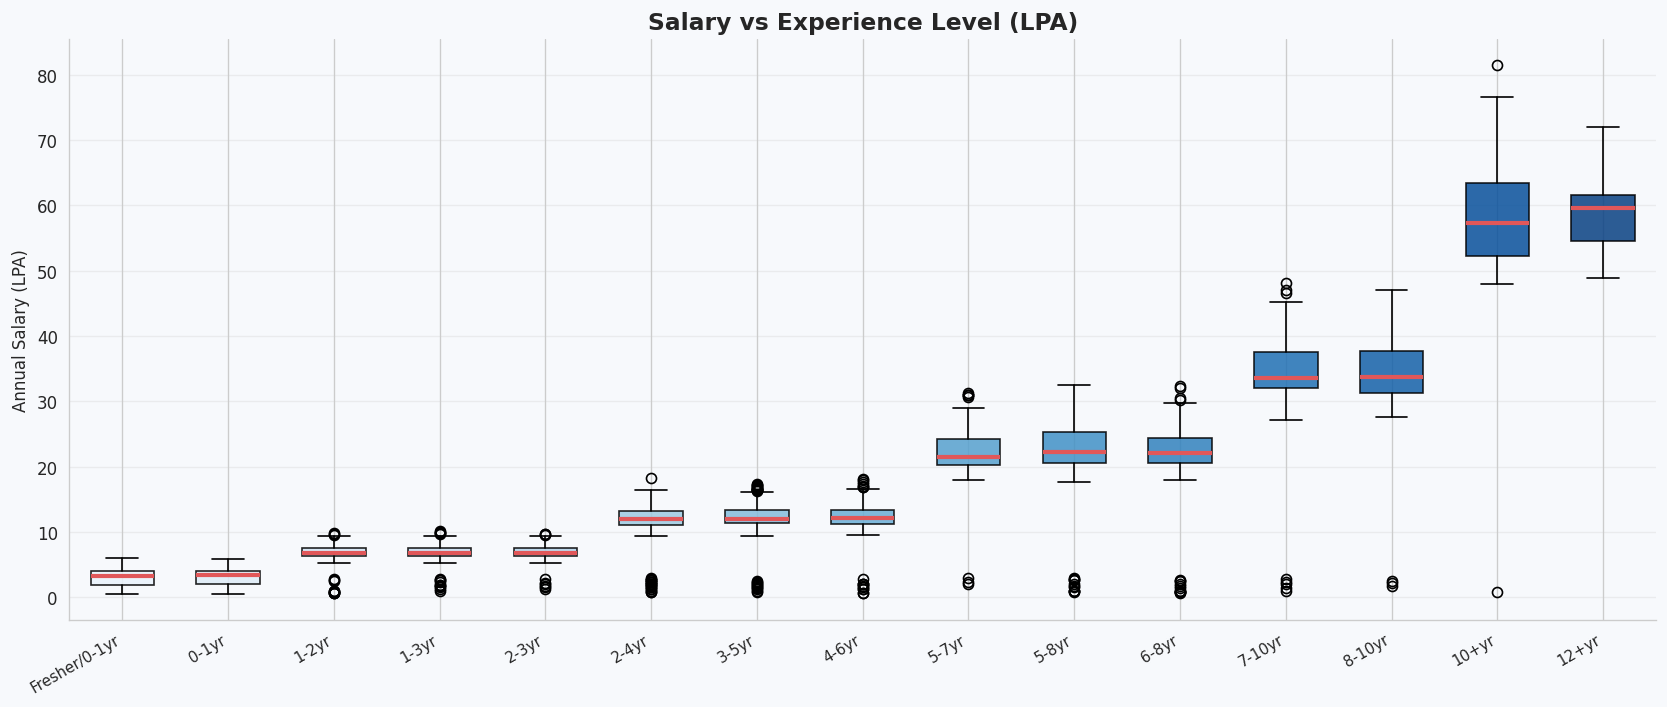

In [16]:
exp_order = ['Fresher / 0-1 years','0-1 years','1-2 years',
             '1-3 years','2-3 years','2-4 years','3-5 years',
             '4-6 years','5-7 years','5-8 years','6-8 years',
             '7-10 years','8-10 years','10+ years','12+ years']

sal_exp = sal_df[sal_df['experience'].isin(exp_order)].copy()
sal_exp['experience'] = pd.Categorical(
    sal_exp['experience'], categories=exp_order, ordered=True)
sal_exp = sal_exp.sort_values('experience')
exp_in_data = [e for e in exp_order
               if e in sal_exp['experience'].unique()]

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
bp3 = ax.boxplot(
    [sal_exp[sal_exp['experience']==e]['salary_lpa'].dropna().values
     for e in exp_in_data],
    patch_artist=True, notch=False, widths=0.6)
blues = sns.color_palette('Blues', len(exp_in_data))
for patch, col in zip(bp3['boxes'], blues):
    patch.set_facecolor(col); patch.set_alpha(0.85)
for med in bp3['medians']:
    med.set_color('#E15759'); med.set_linewidth(2.5)
ax.set_xticklabels(
    [e.replace(' years','yr').replace(' / ','/') for e in exp_in_data],
    rotation=30, ha='right', fontsize=9)
ax.set_title('Salary vs Experience Level (LPA)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Annual Salary (LPA)')
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

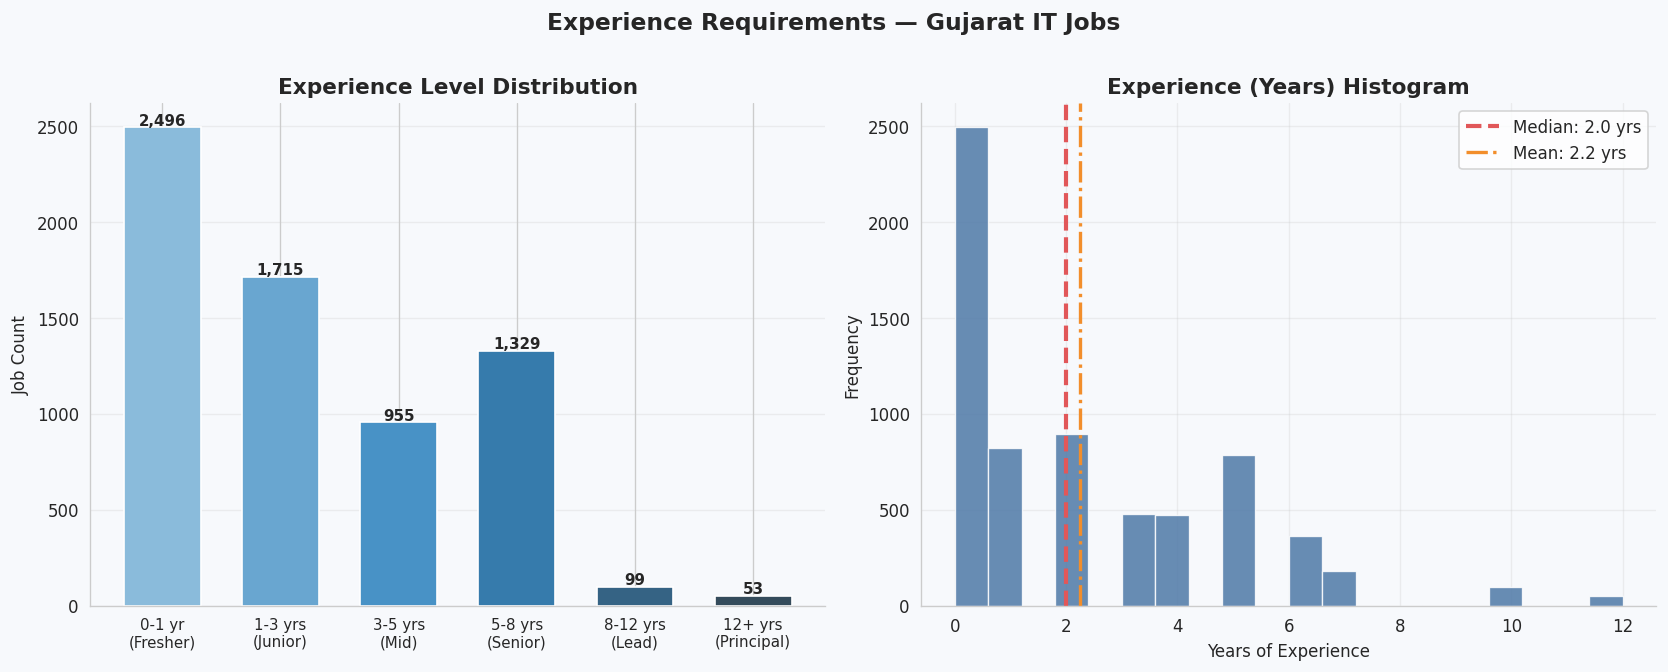

In [17]:
exp_numeric = df['experience_years'].dropna()
bins        = [0, 1, 3, 5, 8, 12, 20]
labels_exp  = ['0-1 yr\n(Fresher)','1-3 yrs\n(Junior)',
               '3-5 yrs\n(Mid)','5-8 yrs\n(Senior)',
               '8-12 yrs\n(Lead)','12+ yrs\n(Principal)']

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.patch.set_facecolor(BG)

ax = axes[0]
ax.set_facecolor(BG)
exp_binned      = pd.cut(exp_numeric, bins=bins, labels=labels_exp, right=False)
exp_bin_counts  = exp_binned.value_counts().reindex(labels_exp)
colors_exp      = sns.color_palette('Blues_d', 6)
bars = ax.bar(range(6), exp_bin_counts.values,
              color=colors_exp, edgecolor='white', width=0.65)
ax.set_xticks(range(6))
ax.set_xticklabels(labels_exp, fontsize=9)
for bar, val in zip(bars, exp_bin_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+10, f'{int(val):,}',
            ha='center', fontweight='bold', fontsize=9)
ax.set_title('Experience Level Distribution',
             fontweight='bold', fontsize=13)
ax.set_ylabel('Job Count')
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)

ax2 = axes[1]
ax2.set_facecolor(BG)
ax2.hist(exp_numeric, bins=20, color='#4E79A7',
         edgecolor='white', linewidth=0.8, alpha=0.85)
ax2.axvline(exp_numeric.median(), color='#E15759', linestyle='--',
            linewidth=2.5, label=f"Median: {exp_numeric.median():.1f} yrs")
ax2.axvline(exp_numeric.mean(), color='#F28E2B', linestyle='-.',
            linewidth=2, label=f"Mean: {exp_numeric.mean():.1f} yrs")
ax2.set_title('Experience (Years) Histogram',
              fontweight='bold', fontsize=13)
ax2.set_xlabel('Years of Experience')
ax2.set_ylabel('Frequency')
ax2.legend(fontsize=10)
ax2.spines[['top','right']].set_visible(False)
ax2.grid(alpha=0.3)

plt.suptitle('Experience Requirements — Gujarat IT Jobs',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

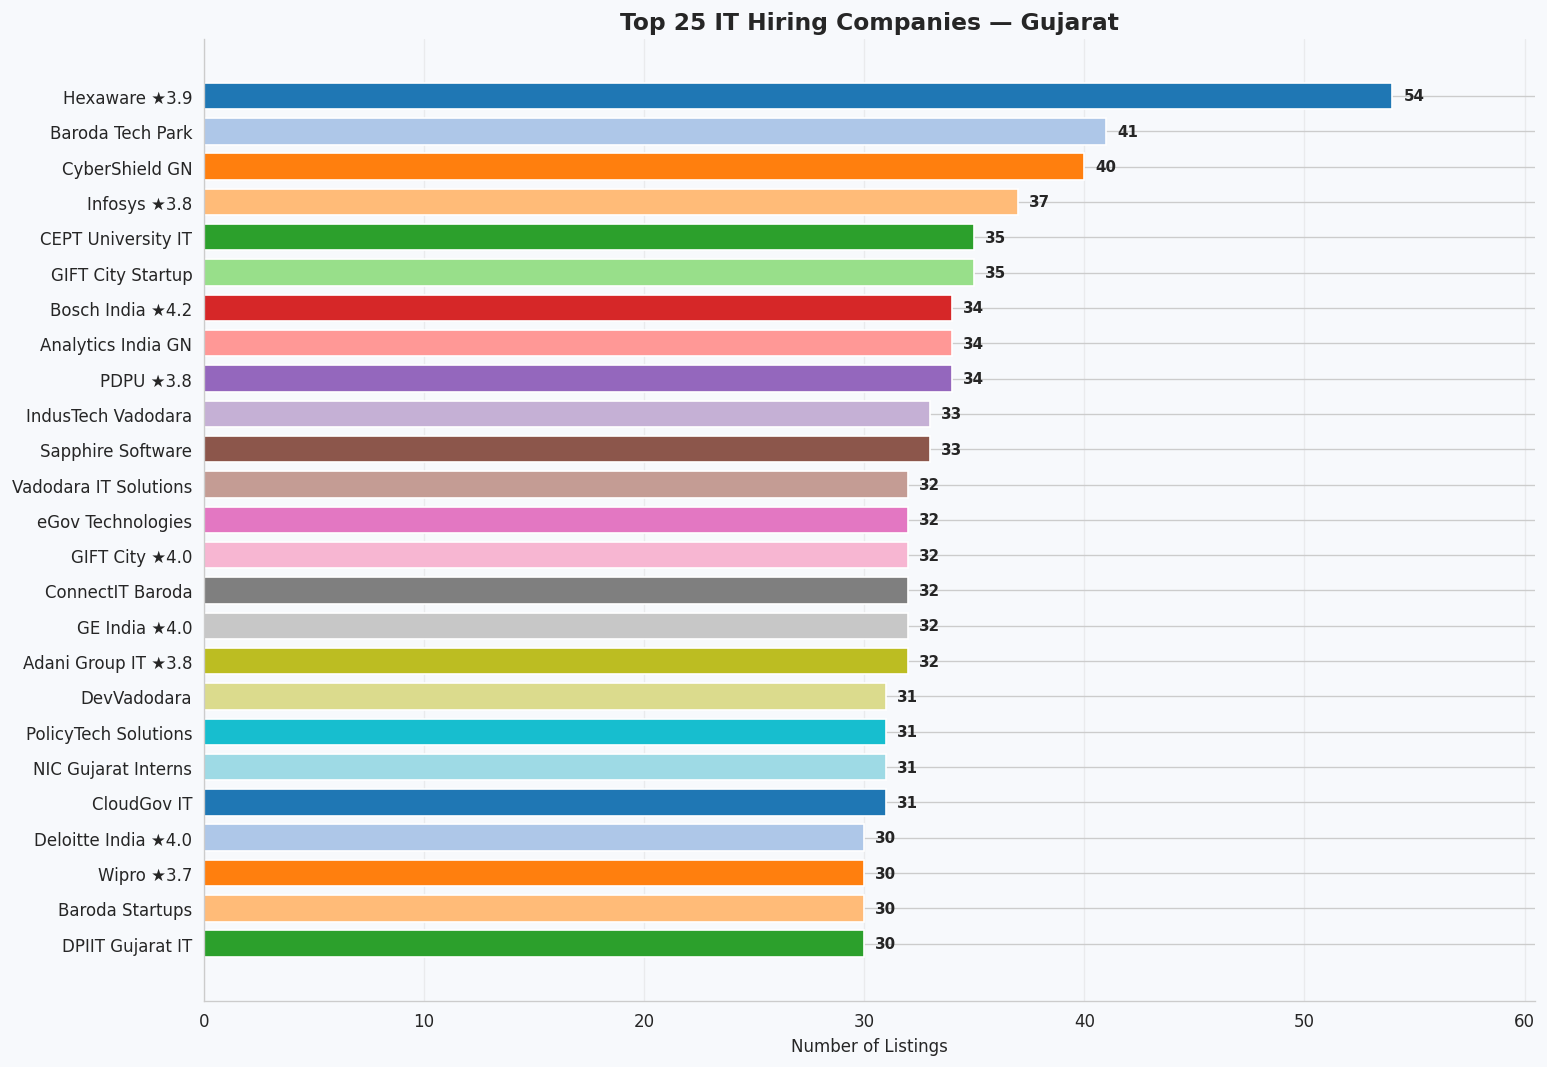

In [18]:
top25_co = df['company_name'].value_counts().head(25)

fig, ax = plt.subplots(figsize=(13, 9))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
colors_co = sns.color_palette('tab20', 25)
bars = ax.barh(top25_co.index[::-1], top25_co.values[::-1],
               color=colors_co[::-1], edgecolor='white', height=0.75)
for bar, val in zip(bars, top25_co.values[::-1]):
    ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
            str(int(val)), va='center', fontsize=9, fontweight='bold')
ax.set_title('Top 25 IT Hiring Companies — Gujarat',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Listings')
ax.set_xlim(0, top25_co.max()*1.12)
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

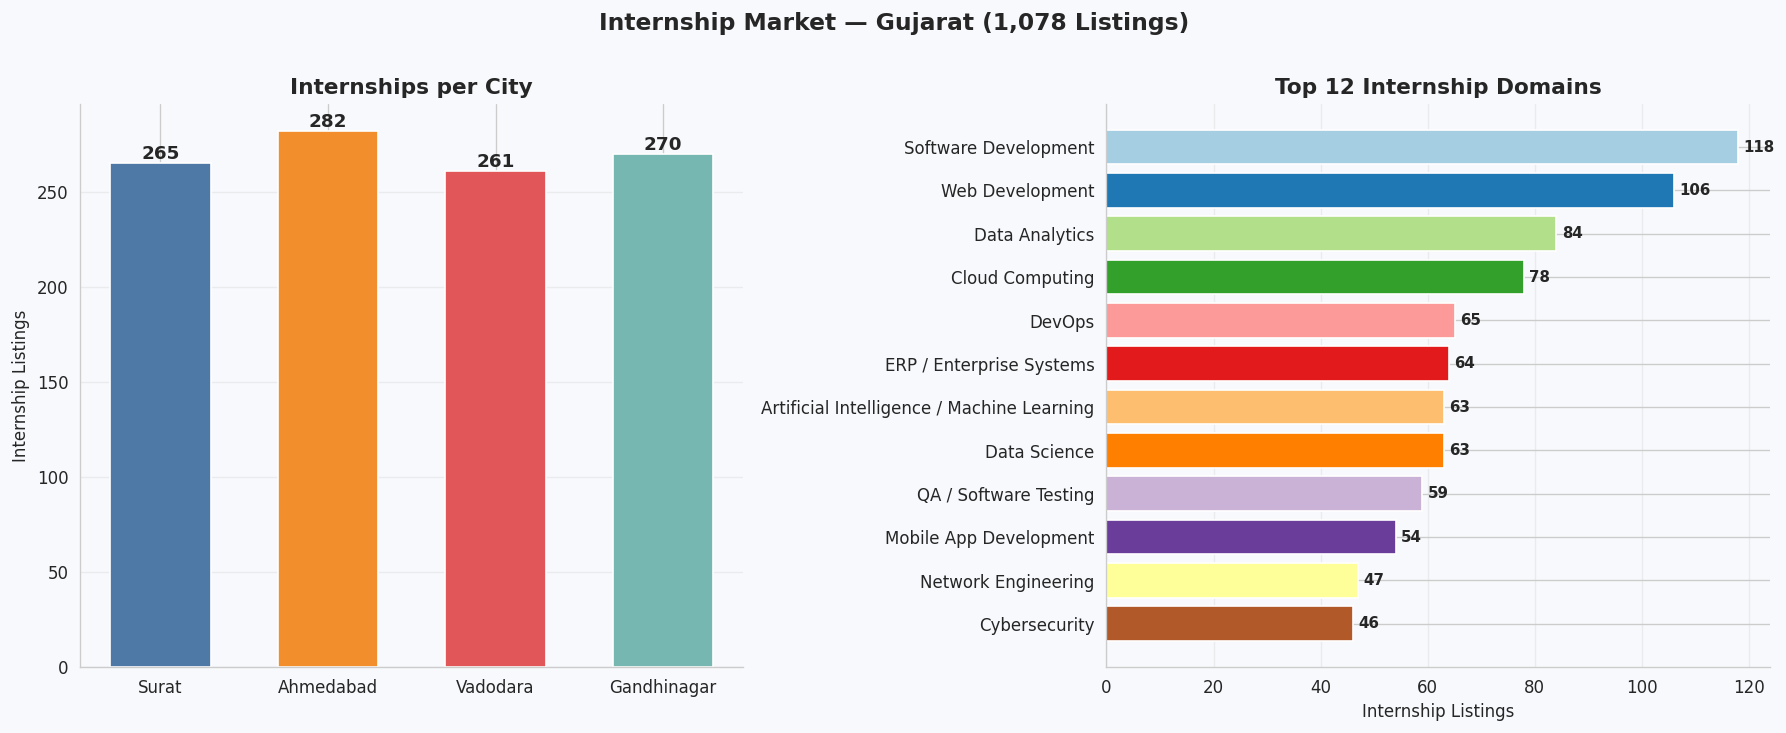

In [19]:
intern_df   = df[df['job_type']=='Internship']
intern_city = intern_df['city'].value_counts().reindex(CITIES)
intern_dom  = intern_df['job_domain'].value_counts().head(12)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor(BG)

ax = axes[0]
ax.set_facecolor(BG)
bars = ax.bar(intern_city.index, intern_city.values,
              color=CITY_COLORS, edgecolor='white', width=0.6)
for bar, val in zip(bars, intern_city.values):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+2, str(int(val)),
            ha='center', fontweight='bold', fontsize=11)
ax.set_title('Internships per City', fontweight='bold', fontsize=13)
ax.set_ylabel('Internship Listings')
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)

ax2 = axes[1]
ax2.set_facecolor(BG)
colors_id = sns.color_palette('Paired', 12)
bars2 = ax2.barh(intern_dom.index[::-1], intern_dom.values[::-1],
                 color=colors_id[::-1], edgecolor='white')
for bar, val in zip(bars2, intern_dom.values[::-1]):
    ax2.text(bar.get_width()+1, bar.get_y()+bar.get_height()/2,
             str(int(val)), va='center', fontsize=9, fontweight='bold')
ax2.set_title('Top 12 Internship Domains',
              fontweight='bold', fontsize=13)
ax2.set_xlabel('Internship Listings')
ax2.spines[['top','right']].set_visible(False)
ax2.grid(axis='x', alpha=0.3)

plt.suptitle(f'Internship Market — Gujarat ({len(intern_df):,} Listings)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

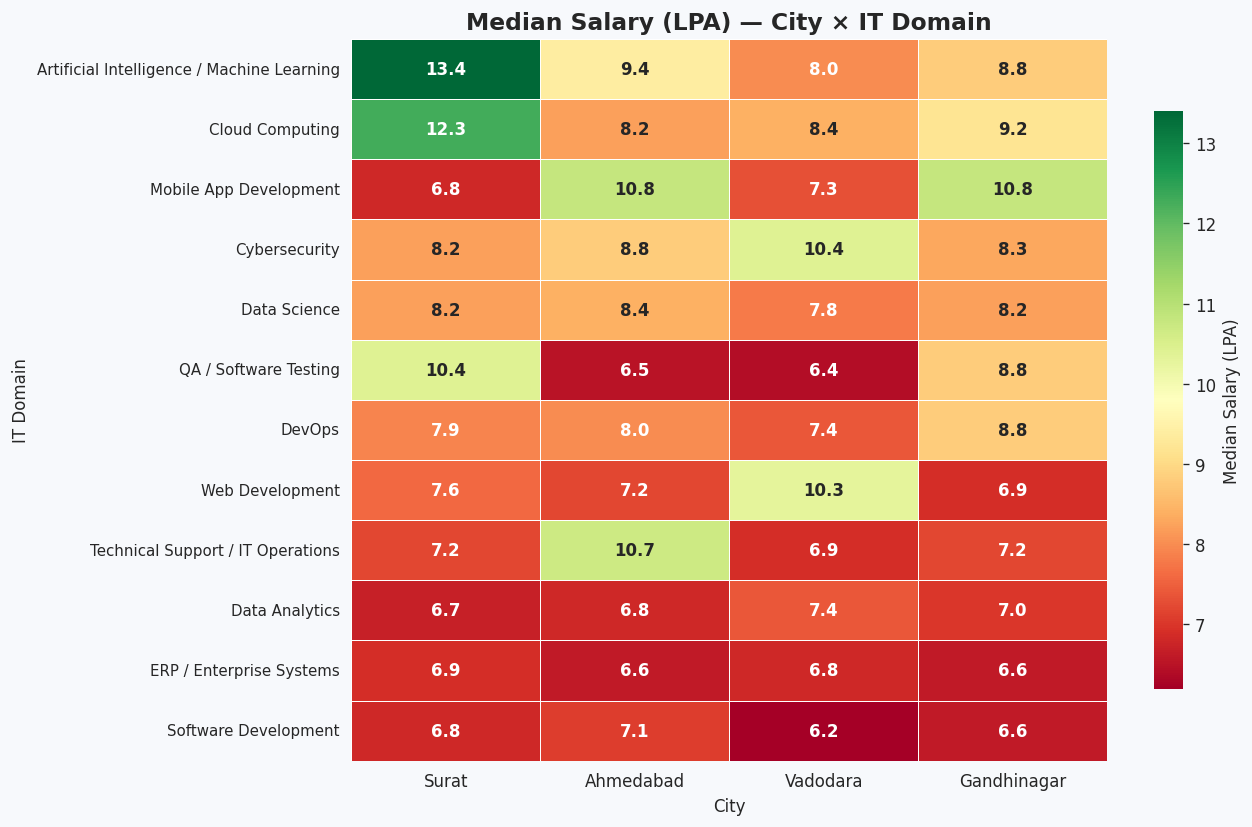

In [20]:
top12_d   = df['job_domain'].value_counts().head(12).index
sal_pivot = sal_df[sal_df['job_domain'].isin(top12_d)].pivot_table(
    index='job_domain', columns='city',
    values='salary_lpa', aggfunc='median', fill_value=0
).reindex(columns=CITIES, fill_value=0)
sal_pivot = sal_pivot.loc[sal_pivot.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor(BG)
sns.heatmap(sal_pivot.round(1), ax=ax, annot=True, fmt='.1f',
            cmap='RdYlGn', linewidths=0.5, linecolor='white',
            cbar_kws={'label':'Median Salary (LPA)','shrink':0.8},
            annot_kws={'size':10, 'weight':'bold'})
ax.set_title('Median Salary (LPA) — City × IT Domain',
             fontsize=14, fontweight='bold')
ax.set_xlabel('City'); ax.set_ylabel('IT Domain')
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0, labelsize=9)
plt.tight_layout()
plt.show()

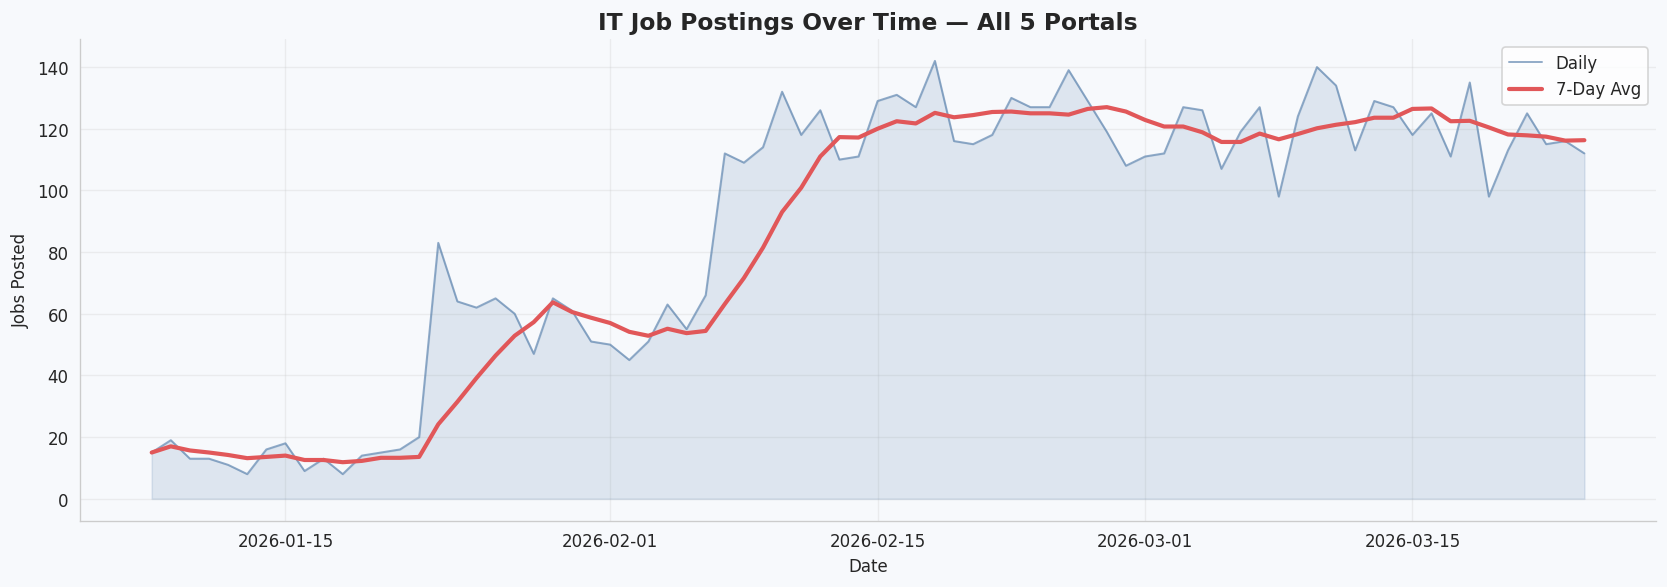

In [21]:
daily = (df.groupby('date_posted').size()
           .reset_index(name='count'))
daily['7d_avg'] = daily['count'].rolling(7, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
ax.fill_between(daily['date_posted'], daily['count'],
                alpha=0.15, color='#4E79A7')
ax.plot(daily['date_posted'], daily['count'],
        color='#4E79A7', linewidth=1.2, alpha=0.6, label='Daily')
ax.plot(daily['date_posted'], daily['7d_avg'],
        color='#E15759', linewidth=2.5, label='7-Day Avg')
ax.set_title('IT Job Postings Over Time — All 5 Portals',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Jobs Posted')
ax.legend(fontsize=10)
ax.spines[['top','right']].set_visible(False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
city_leader       = df['city'].value_counts().idxmax()
top_domain        = df['job_domain'].value_counts().idxmax()
top_skill         = all_skills.idxmax()
top_company       = df['company_name'].value_counts().idxmax()
top_portal        = df['source_portal'].value_counts().idxmax()
median_sal        = sal_df['salary_lpa'].median()
avg_exp           = df['experience_years'].mean()
total_internships = df[df['job_type']=='Internship'].shape[0]

print('=' * 62)
print('   💡 COMPLETE INSIGHTS — GUJARAT IT JOB MARKET')
print('=' * 62)
print(f'''
  📊 DATASET
  ──────────────────────────────────────────
  Total Records      : {len(df):,}
  Portals            : 5 (Naukri, LinkedIn, Indeed,
                       Glassdoor, Internshala)
  IT Domains         : {df['job_domain'].nunique()}
  Unique Companies   : {df['company_name'].nunique():,}

  🏆 RANKINGS
  ──────────────────────────────────────────
  #1 City            : {city_leader}
  #1 Domain          : {top_domain}
  #1 Skill           : {top_skill}
  #1 Company         : {top_company}
  #1 Portal (volume) : {top_portal}

  💰 SALARY INSIGHTS
  ──────────────────────────────────────────
  Median Salary      : ₹{median_sal:.1f} LPA
  Avg Experience     : {avg_exp:.1f} years
  Fresher  (0-1 yr)  : ₹2.5 – 5.5 LPA
  Junior   (1-3 yr)  : ₹4.0 – 9.0 LPA
  Mid      (3-5 yr)  : ₹7.0 – 16 LPA
  Senior   (5-8 yr)  : ₹14  – 28 LPA
  Lead     (7-10 yr) : ₹22  – 42 LPA

  🎓 FRESHER MARKET
  ──────────────────────────────────────────
  Total Internships  : {total_internships:,}
  Best Portal        : Internshala
  Best Cities        : Ahmedabad & Surat

  🏙️  CITY SPECIALISATIONS
  ──────────────────────────────────────────''')

for city, color in zip(CITIES, ['🔵','🟠','🔴','🟢']):
    city_df  = df[df['city']==city]
    top_d    = city_df['job_domain'].value_counts().idxmax()
    top_s    = (city_df['skills'].dropna()
                .str.split(', ').explode()
                .str.strip().str.title()
                .value_counts().idxmax())
    city_sal = sal_df[sal_df['city']==city]['salary_lpa']
    avg_s    = city_sal.mean() if len(city_sal) > 0 else 0
    interns  = city_df[city_df['job_type']=='Internship'].shape[0]
    print(f'''  {color} {city}
     Jobs       : {len(city_df):,}
     Top Domain : {top_d}
     Top Skill  : {top_s}
     Avg Salary : ₹{avg_s:.1f} LPA
     Internships: {interns}''')

print('''
  📈 GROWTH SIGNALS
  ──────────────────────────────────────────
  AI/ML roles growing fastest in Ahmedabad
  Cloud & Cybersecurity surging in Gandhinagar
  Embedded/IoT strong and stable in Vadodara
  Web Development remains #1 across all cities
  Python + SQL + Cloud = most future-proof stack
''')
print('=' * 62)

   💡 COMPLETE INSIGHTS — GUJARAT IT JOB MARKET

  📊 DATASET
  ──────────────────────────────────────────
  Total Records      : 6,647
  Portals            : 5 (Naukri, LinkedIn, Indeed,
                       Glassdoor, Internshala)
  IT Domains         : 20
  Unique Companies   : 361

  🏆 RANKINGS
  ──────────────────────────────────────────
  #1 City            : Surat
  #1 Domain          : Web Development
  #1 Skill           : Python
  #1 Company         : Hexaware ★3.9
  #1 Portal (volume) : Internshala

  💰 SALARY INSIGHTS
  ──────────────────────────────────────────
  Median Salary      : ₹7.6 LPA
  Avg Experience     : 2.2 years
  Fresher  (0-1 yr)  : ₹2.5 – 5.5 LPA
  Junior   (1-3 yr)  : ₹4.0 – 9.0 LPA
  Mid      (3-5 yr)  : ₹7.0 – 16 LPA
  Senior   (5-8 yr)  : ₹14  – 28 LPA
  Lead     (7-10 yr) : ₹22  – 42 LPA

  🎓 FRESHER MARKET
  ──────────────────────────────────────────
  Total Internships  : 1,078
  Best Portal        : Internshala
  Best Cities        : Ahmedabad & Sur